In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
# from OptiNet import OptiNet
import cvxpy as cp
from cvxpylayers.torch import CvxpyLayer
import sympy as sp
import sympy.diffgeom as dg
import torch
import torch.nn as nn
from torch.utils.data import Dataset


In [2]:
print(f"PyTorch version: {torch.__version__}")
print(f"Is CUDA available: {torch.cuda.is_available()}")
print(f"CUDA Version PyTorch expects: {torch.version.cuda}")
device = torch.device("cuda:0" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
print(device)

PyTorch version: 2.6.0+cu124
Is CUDA available: True
CUDA Version PyTorch expects: 12.4
cuda:0


In [3]:
#Import files
data_dir = Path("data")
episodes = []
for fp in sorted(data_dir.glob("data*.npz")):
    z = np.load(fp)
    episodes.append(z["data"]) 
len(episodes), episodes[1].shape

(41, (102, 13))

41
total_timestep_amount 8232


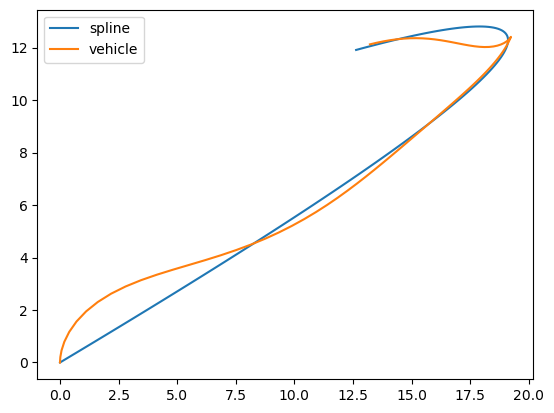

In [4]:
#Look at file data.
episode_data = episodes[1]
episode_data[100:150, :14]
total_timestep_amount = 0  #number should match X.shape[0] and Y.shape[0]

for i in range(len(episodes)):
    # print(episodes[i].shape)
    total_timestep_amount += episodes[i].shape[0]
print(len(episodes))
print("total_timestep_amount", total_timestep_amount)
plt.plot(episode_data[:, 0], episode_data[:, 1], label='spline')
plt.plot(episode_data[:, 6], episode_data[:, 7], label = 'vehicle')
plt.legend()
plt.show()

In [21]:
#Structure input files for LSTM
from copy import deepcopy
lookback = 5

def calculate_barrier_function(state, ko_data):
    #hx is CBF
    x = state[0]
    y = state[1]
    x_ko = ko_data[0]
    y_ko = ko_data[1]
    radius_ko = ko_data[2]

    hx = np.sqrt((x-x_ko)**2 + (y-y_ko)**2)-radius_ko
    return hx
     
def parse_data(data, lookback, ko_data): #TODO: Add padding so that first few values can be added to train
    data = deepcopy(data)
    X= []
    Y = []    #NN outputs force and torque, each Y_i should be accompanied with states from X_i-5 to X_i
    # print (data[1].shape)
    print("data length:", len(data))
    for episode_data in data: #go across all episodes  

        # print("episode_data",episode_data.shape)
        Y_new = episode_data[lookback:, 11:13] #Get all force and torque vectors from 1 episode. Ignore first lookback elements since no history
        # print("Y_new Shape", Y_new.shape)
        Y.append(Y_new)

        episode_length = episode_data.shape[0]
        #Need X shape (total length, lookback, data dim)
        episode_data_x = episode_data[:, 0:11] #shape 2000, 11
        
        h_values = np.array([calculate_barrier_function(row, ko_data) for row in episode_data_x])
        episode_data_x_with_h = np.column_stack((episode_data_x, h_values))
        # print("episode_data_x_with_h shape:", episode_data_x_with_h.shape)
        x_sliding_window = []

        for j in range(episode_length - lookback):
            # Grab a slice of 'lookback' length: from j to j+lookback
            window = episode_data_x_with_h[j : j + lookback]
            x_sliding_window.append(window)
            
        X.append(np.array(x_sliding_window))

    #Combine data cross all episodes into one
    print(Y[0].shape)
    print(X[0].shape)
    X = np.concatenate(X, axis=0)
    Y = np.concatenate(Y, axis=0)
    return X, Y


#insert keep out region into training data set to calculate hf
KO_DATA = [-100, -100, 0.001]    #x, y, rad

X, Y = parse_data(episodes, lookback, KO_DATA)
print("X Shape",X.shape)
print("Y Shape", Y.shape)
# Y[1000:1100, :]


data length: 41
(297, 2)
(297, 5, 12)
X Shape (8027, 5, 12)
Y Shape (8027, 2)


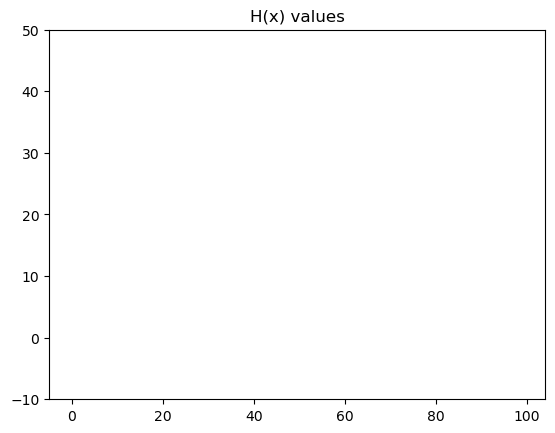

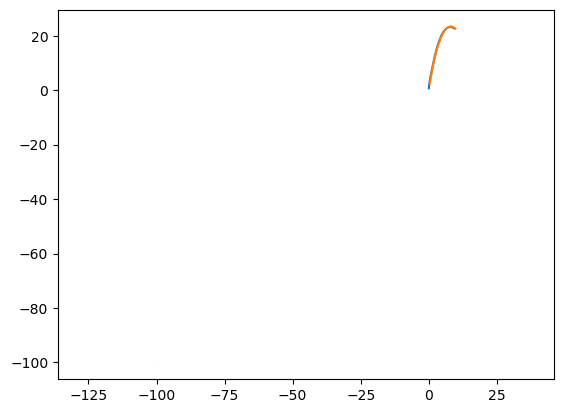

In [22]:
#Validate Data

#make plot of x, y, 
present_values = X[0:100, -1, :]
present_values.shape

h_x = present_values[:, -1]
x_spline = present_values[:, 0]
y_spline = present_values[:, 1]
x_cur = present_values[:, 6]
y_cur = present_values[:, 7]

plt.plot(h_x)
plt.title("H(x) values")
plt.ylim(-10, 50)
plt.show()

fig, ax = plt.subplots()
ax.plot(x_cur, y_cur, label='Current Path')
ax.plot(x_spline, y_spline, label='Spline')
circle_x, circle_y, radius = KO_DATA[0], KO_DATA[1], KO_DATA[2] # Replace with your actual values
circle = plt.Circle((circle_x, circle_y), radius, color='r', fill=False, label='Boundary')
ax.add_patch(circle)
ax.set_aspect('equal', adjustable='datalim')

plt.legend
plt.show()


In [23]:

split_index = int(len(X) * 0.95)
X_train = X[:split_index]
X_test = X[split_index:]

Y_train = Y[:split_index]
Y_test = Y[split_index:]

X_train = torch.tensor(X_train).float()
Y_train = torch.tensor(Y_train).float()
X_test = torch.tensor(X_test).float()
Y_test = torch.tensor(Y_test).float()


X_train.shape, X_test.shape, Y_train.shape, Y_test.shape


(torch.Size([7625, 5, 12]),
 torch.Size([402, 5, 12]),
 torch.Size([7625, 2]),
 torch.Size([402, 2]))

In [24]:
class TrajectoryDataset(Dataset):
    def __init__(self, X, Y):
        self.X = X
        self.Y = Y

    def __len__(self):
        return len(self.X)

    def __getitem__(self, i):
        return self.X[i], self.Y[i]

train_dataset = TrajectoryDataset(X_train, Y_train)
test_dataset = TrajectoryDataset(X_test, Y_test)

from torch.utils.data import DataLoader

batch_size = 16

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)


In [25]:
for _, batch in enumerate(train_loader):
    x_batch, y_batch = batch[0].to(device), batch[1].to(device)
    print(x_batch.shape, y_batch.shape)
    break



torch.Size([16, 5, 12]) torch.Size([16, 2])


In [37]:
class LSTM(nn.Module):

    # input size = number features = 12
    #hidden size can be anything, use 20 for now
    #num_stacked_layers, idk what it does
    def __init__(self, input_size, hidden_size, num_stacked_layers):
        super().__init__()
        self.hidden_size = hidden_size
        self.num_stacked_layers = num_stacked_layers
        self.lstm = nn.LSTM(input_size, hidden_size, num_stacked_layers,
                            batch_first=True)
        self.fc = nn.Linear(hidden_size, 2)

        # u_f = cp.Variable(1)   
        # A = cp.Parameter(1)
        # b = cp.Parameter(1)
        # u_f_nom_param = cp.Parameter(1)
        # constraints = [A @ u_f + b >= 0]
        # objective = cp.Minimize(0.5 * cp.pnorm(u_f-u_f_nom_param, p=2))
        # problem = cp.Problem(objective, constraints)
        # assert problem.is_dpp()
        # self.layer = CvxpyLayer(problem, parameters=[A, b, u_f_nom_param], variables=[u_f]).to(device)

        #trying with no CBF constraint
        u_f = cp.Variable(1)   
        u_f_nom_param = cp.Parameter(1)
        objective = cp.Minimize(0.5 * cp.pnorm(u_f-u_f_nom_param, p=2))
        problem = cp.Problem(objective)
        assert problem.is_dpp()
        self.layer = CvxpyLayer(problem, parameters=[u_f_nom_param], variables=[u_f]).to(device)


    def get_cbf_coeff(self, state, ko_data, k1, k2): 
        
        #x shape torch.Size([16, 5, 12])
        current_state = state[:, -1, :]  #only want last time of LSTM

        x = current_state[:,0]
        y = current_state[:,1]
        theta = current_state[:,2]
        v = current_state[:,3]
        omega = current_state[:,4]
        x_ko = ko_data[0]
        y_ko = ko_data[1]
        r_ko = ko_data[2]

        # print(f"State device: {state.device}")
        # print(f"KO data device: {ko_data.device}")

        #helper variables
        x_err = x_ko - x
        y_err = y_ko - y
        v_err = x_err**2 + y_err**2

        r1 = (v_err**(7/2)) * x_err
        r2 = (v_err**(7/2)) * y_err
        r3 = (v_err**(5/2)) * (x_err**2)
        r4 = (v_err**(5/2)) * (y_err**2)
        r5 = (v_err**(5/2)) * x_err * y_err

        #Coeff for input
        u_f_coeff = (2*r1*torch.cos(theta) + 2*r2*torch.sin(theta)) / 2 * v_err**4

        #other coeffs
        term1 = -2 * k1 * k2 * (v_err**(9/2))
        term2 = 2 * k1 * k2 * v_err**4 * r_ko
        term3 = -2 * r1 * torch.sin(theta) * v * omega
        term4 = 2 * r2 * torch.cos(theta) * v * omega
        term5 = r3 * torch.cos(2 * theta) * (v**2)
        term6 = r3 * (v**2)
        term7 = -r4 * torch.cos(2 * theta) * (v**2) 
        term8 = r4 * (v**2)
        term9 = 2 * r5 * torch.sin(2 * theta) * (v**2)
        term10 = -2 * (v_err**(7/2)) * (v**2)

        numerator = -(term1 + term2 + term3 + term4 + term5 + 
                        term6 + term7 + term8 + term9 + term10)

        denominator = 2 * v_err**4

        const_coeff = numerator / denominator

        return u_f_coeff, const_coeff



    def forward(self, x, ko_data, k1, k2):
        # print("x shape" ,x.shape)
        batch_size = x.size(0)
        h0 = torch.zeros(self.num_stacked_layers, batch_size, self.hidden_size).to(device)
        c0 = torch.zeros(self.num_stacked_layers, batch_size, self.hidden_size).to(device)

        out, _ = self.lstm(x, (h0, c0))
        # print("out shape 1", out.shape)

        out = self.fc(out[:, -1, :]) # get only last value in LSTM output
        # print("out shape 2", out.shape)
        u_f_nom = out[:, 0:1]  #keep 16, 1 shape
        
        u_f_coeff, const_coeff = self.get_cbf_coeff(x, ko_data, k1, k2)

        
        # A_tch = u_f_coeff.to(device).reshape(-1, 1) #add extra dim for cvxpylayers
        # b_tch = const_coeff.to(device).reshape(-1, 1)
        A_tch = u_f_coeff.reshape(-1, 1).cpu()
        b_tch = const_coeff.reshape(-1, 1).cpu()
        u_f_nom_cpu = u_f_nom.cpu()

        # solve the problem
        try:
            # (solution_cpu,) = self.layer(A_tch, b_tch, u_f_nom_cpu)
            (solution_cpu,) = self.layer(u_f_nom_cpu)

            solution = solution_cpu.to(device)

        except:
            print("Solution failed :( Resorting to unsafe value")
            solution = u_f_nom

        return solution.float()

model = LSTM(12, 20, 1)

model.to(device)
print(device)
model


cuda:0


LSTM(
  (lstm): LSTM(12, 20, batch_first=True)
  (fc): Linear(in_features=20, out_features=2, bias=True)
  (layer): CvxpyLayer()
)

In [40]:
loss_function = nn.MSELoss()
learning_rate = 0.001
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
num_epochs = 4
k1 = torch.tensor([0.1])
k2 = torch.tensor([0.1])



def train_one_epoch():
    model.train(True)
    print(f'Epoch: {epoch + 1}')
    running_loss = 0.0

    for batch_index, batch in enumerate(train_loader):

        x_batch, y_batch = batch[0].to(device), batch[1].to(device) #make things on device
        ko_data_torch = torch.tensor(KO_DATA)
        ko_data_torch = ko_data_torch.to(device)
        k1_torch = k1.to(device)
        k2_torch = k2.to(device)

        output = model(x_batch, ko_data_torch, k1_torch, k2_torch)     
        loss = loss_function(output, y_batch)
        running_loss += loss.item()

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        if batch_index % 100 == 99:  # print every 100 batches
            avg_loss_across_batches = running_loss / 100
            print('Batch {0}, Loss: {1:.3f}'.format(batch_index+1,
                                                    avg_loss_across_batches))
            running_loss = 0.0
    print()

# def validate_one_epoch():
#     model.train(False)
#     running_loss = 0.0

#     for batch_index, batch in enumerate(test_loader):
#         x_batch, y_batch = batch[0].to(device), batch[1].to(device)

#         with torch.no_grad():
#             output = model(x_batch, KO_DATA, k1, k2)
#             loss = loss_function(output, y_batch)
#             running_loss += loss.item()

#     avg_loss_across_batches = running_loss / len(test_loader)

#     print('Val Loss: {0:.3f}'.format(avg_loss_across_batches))
#     print('***************************************************')
#     print()

In [41]:
for epoch in range(num_epochs):
    train_one_epoch()
    # validate_one_epoch()
'''
For soem reason solver cannot solve when KO is far away but can solve when close by???
'''

Epoch: 1
Batch 100, Loss: 3.518
Batch 200, Loss: 2.174
Batch 300, Loss: 3.548
Batch 400, Loss: 3.529

Epoch: 2
Batch 100, Loss: 2.512
Batch 200, Loss: 2.937
Batch 300, Loss: 2.947
Batch 400, Loss: 1.878

Epoch: 3
Batch 100, Loss: 4.659
Batch 200, Loss: 2.099
Batch 300, Loss: 2.333
Batch 400, Loss: 2.228

Epoch: 4
Batch 100, Loss: 2.413
Batch 200, Loss: 1.741
Batch 300, Loss: 4.122
Batch 400, Loss: 2.847



'\nFor soem reason solver cannot solve when KO is far away but can solve when close by???\n'

In [ ]:
model.train(False)



with torch.no_grad():
    ko_data_torch = torch.tensor(KO_DATA)
    ko_data_torch = ko_data_torch.to(device)
    k1_torch = k1.to(device)
    k2_torch = k2.to(device)
    predicted = model(X_test.to(device),  ko_data_torch, k1_torch, k2_torch).to('cpu').numpy()


plt.plot(Y_train[:,0], label='Actual force')
plt.plot(predicted[:,0], label='Predicted force')
plt.xlabel('t')
plt.ylim(-10, 10)
plt.ylabel('force')
plt.legend()
plt.show()


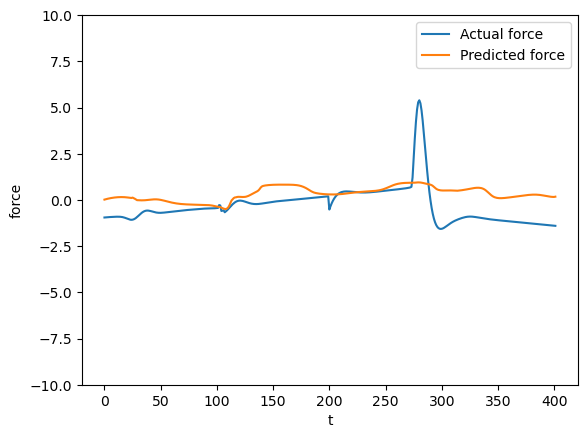

In [42]:
#Test data

with torch.no_grad():
    ko_data_torch = torch.tensor(KO_DATA)
    ko_data_torch = ko_data_torch.to(device)
    k1_torch = k1.to(device)
    k2_torch = k2.to(device)
    predicted = model(X_test.to(device), ko_data_torch, k1_torch, k2_torch).to('cpu').numpy()


plt.plot(Y_test[:,0], label='Actual force')
plt.plot(predicted[:,0], label='Predicted force')
plt.xlabel('t')
plt.ylim(-10, 10)
plt.ylabel('force')
plt.legend()
plt.show()